# **RQ1**: Number of neighbors per node over time

For each node in every snapshot, compute the node's degree and record it in a CSV file.

In [1]:
import pandas as pd
import igraph as ig
from pathlib import Path
import time

graph_dir = Path("networks")        
output_dir = Path("degree_csv_igraph_snapshot")
output_dir.mkdir(exist_ok=True)

percentile = 99

print("[START] Estrazione degree dai grafi igraph")

for snap in range(1, 8):
    t0 = time.time()

    graph_file = graph_dir / f"graph_snap{snap}_p{percentile}.igp"
    output_csv = output_dir / f"node_degree_snap{snap}_p{percentile}.csv"

    print(f"\n[SNAPSHOT {snap}]")

    # importo g
    g = ig.Graph.Read_Pickle(graph_file)

   
    degrees = g.degree()   # numero di vicini

   
    tokens = g.vs["token"]

    df_out = pd.DataFrame({
        "token": tokens,
        "degree": degrees
    })

    df_out.to_csv(output_csv, index=False)

    print(
        f"[DONE] nodi={g.vcount()}, archi={g.ecount()} "
        f"in {time.time() - t0:.2f}s"
    )

print("\n[TOTAL] Tutti i CSV generati")


[START] Estrazione degree dai grafi igraph

[SNAPSHOT 1]
[DONE] nodi=34742, archi=6102158 in 5.34s

[SNAPSHOT 2]
[DONE] nodi=28017, archi=3951749 in 3.31s

[SNAPSHOT 3]
[DONE] nodi=28028, archi=3923413 in 2.68s

[SNAPSHOT 4]
[DONE] nodi=34431, archi=6018030 in 6.14s

[SNAPSHOT 5]
[DONE] nodi=37089, archi=6906542 in 10.63s

[SNAPSHOT 6]
[DONE] nodi=37658, archi=7168835 in 7.82s

[SNAPSHOT 7]
[DONE] nodi=31000, archi=4792121 in 5.81s

[TOTAL] Tutti i CSV generati


# Individual shrinkage Si
Compute the individual shrinkage for each node at each time step.
Use the first snapshot in which the word appears as the baseline (t0).

In [56]:
import pandas as pd
from pathlib import Path

degree_dir = Path("degree_csv_igraph_snapshot")
output_csv = Path("shrinkage_i.csv")

snapshots = range(1, 8)

# --- leggo tutti i degree ---
all_degrees = {}  # all_degrees[snap][token] = degree
for snap in snapshots:
    df = pd.read_csv(degree_dir / f"node_degree_snap{snap}_p99.csv")
    
    # Convertiamo i token in stringa e ignoriamo NaN
    df = df.dropna(subset=["token"])
    df["token"] = df["token"].astype(str)
    
    all_degrees[snap] = dict(zip(df["token"], df["degree"]))

# --- trovo primo snapshot per ogni token ---
first_snap = {}
for snap in snapshots:
    for token in all_degrees[snap]:
        if token not in first_snap:
            first_snap[token] = snap

# --- calcolo in quanti snapshot compare ogni token ---
appear_count = {token: 0 for token in first_snap}
for snap in snapshots:
    for token in first_snap:
        if all_degrees[snap].get(token, 0) > 0:
            appear_count[token] += 1

# --- filtro token: almeno 5 snapshot ---
tokens = sorted([tok for tok, count in appear_count.items() if count >= 5])

# --- calcolo shrinkage per tutti i token filtrati ---
shrinkage_data = {"token": tokens}

for snap in snapshots:
    shrink_values = []
    for token in tokens:
        t0 = first_snap[token]
        degree_t0 = all_degrees[t0].get(token, 0)
        degree_t = all_degrees[snap].get(token, 0)  # se non presente → 0
        if degree_t0 == 0:
            s = None  # baseline assente
        else:
            s = 1 - (degree_t / degree_t0)
        shrink_values.append(s)
    shrinkage_data[f"shrinkage_snap{snap}"] = shrink_values

df_shrink_filtered = pd.DataFrame(shrinkage_data)
df_shrink_filtered.to_csv(output_csv, index=False)

print(f"[DONE] Shrinkage calcolato per token in ≥5 snapshot in {output_csv}")


[DONE] Shrinkage calcolato per token in ≥5 snapshot in shrinkage_i.csv


In [57]:
len(df_shrink_filtered)

27144

# S_aggr
Compute the aggregated shrinkage for each node.

In [58]:
import pandas as pd
from pathlib import Path
import numpy as np

# CSV shrinkage
shrink_csv = "shrinkage_i.csv"
df_shrink = pd.read_csv(shrink_csv)

snapshots = range(1, 8)
freq_dir = Path("../embedding/frequencies_all")

# df delle frequenze per tutti gli snapshot
freq_dfs = []
for snap in snapshots:
    freq_file = freq_dir / f"vocab_freq_snap{snap}.csv"

    df_freq = pd.read_csv(freq_file)

    df_freq = df_freq.rename(columns={
        "word": "token",
        "frequency": f"freq_snap{snap}"
    })

    # filtra solo token presenti nello shrinkage
    df_freq = df_freq[df_freq["token"].isin(df_shrink["token"])]

    freq_dfs.append(df_freq)

# Merge di tutte le frequenze
df_freq_all = freq_dfs[0]
for df_f in freq_dfs[1:]:
    df_freq_all = df_freq_all.merge(df_f, on="token", how="outer")

# allineamento finale
df_all = df_shrink.merge(df_freq_all, on="token", how="inner")

# inizializzazione vettoriale
numeratore = pd.Series(0.0, index=df_all.index)
denominatore = pd.Series(0.0, index=df_all.index)

for snap in snapshots:
    s_col = f"shrinkage_snap{snap}"
    w_col = f"freq_snap{snap}"

    numeratore += df_all[s_col].fillna(0) * df_all[w_col].fillna(0)
    denominatore += df_all[w_col].fillna(0)

# S_aggregato (evita divisione per zero)
df_all["S_aggregato"] = np.where(
    denominatore > 0,
    numeratore / denominatore,
    np.nan
)

df_result = df_all[["token", "S_aggregato"]]
df_result.to_csv("shrinkage_aggr_filtered.csv", index=False)

print(df_result.head())


     token  S_aggregato
0      -l'     0.741229
1     aalà     0.778104
2    abaco     0.616247
3  abanese     0.040153
4    abare     0.758155


In [59]:
len(df_result)

27144

Describe S_aggr

In [60]:
import pandas as pd

df = pd.read_csv("shrinkage_aggr_filtered.csv")

df["S_aggregato"].describe()


count    27144.000000
mean        -0.547879
std          2.092318
min        -90.380968
25%         -0.698958
50%         -0.143077
75%          0.222442
max          0.939238
Name: S_aggregato, dtype: float64

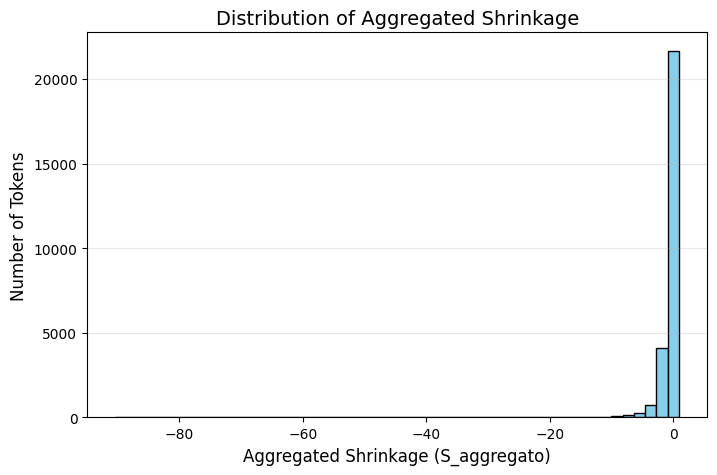

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["S_aggregato"].dropna(), bins=50, color="skyblue", edgecolor="black")
plt.xlabel("Aggregated Shrinkage (S_aggregato)", fontsize=12)
plt.ylabel("Number of Tokens", fontsize=12)
plt.title("Distribution of Aggregated Shrinkage", fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.show()


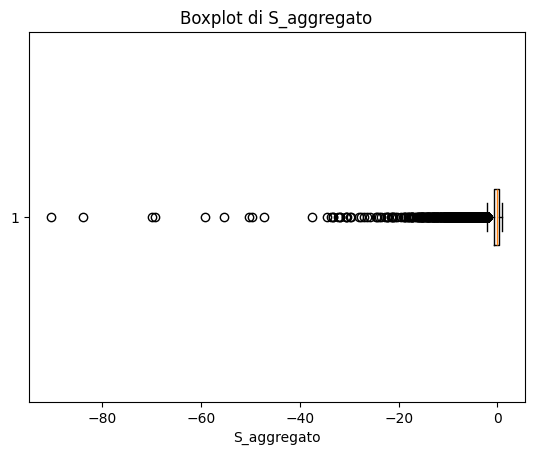

In [62]:
plt.figure()
plt.boxplot(df["S_aggregato"].dropna(), vert=False)
plt.xlabel("S_aggregato")
plt.title("Boxplot di S_aggregato")
plt.show()


In [63]:
df["class"] = "neutral"
df.loc[df["S_aggregato"] > 0, "class"] = "shrinkage"
df.loc[df["S_aggregato"] < 0, "class"] = "expansion"

df["class"].value_counts(normalize=True) * 100


class
expansion    59.622753
shrinkage    40.369879
neutral       0.007368
Name: proportion, dtype: float64

In [64]:
# top parole con espansione forte
df.sort_values("S_aggregato", ascending=True).head(20)

,token,S_aggregato,class
8967,eleno,-90.380968,expansion
479,adesivo,-83.979849,expansion
18591,plus,-70.030433,expansion
7441,decure,-69.424550,expansion
8958,elegia,-59.177193,expansion
7782,dev,-55.439665,expansion
8899,egisto,-50.397436,expansion
19713,pula,-49.754137,expansion
26847,visionario,-47.352418,expansion
13087,insembre,-37.607458,expansion


In [65]:
# top parole con shrinkage forte
df.sort_values("S_aggregato", ascending=False).head(20)

,token,S_aggregato,class
11878,iceberg,0.939238,shrinkage
9999,fax,0.930341,shrinkage
2922,azeglio,0.919378,shrinkage
13883,laccio,0.919320,shrinkage
5276,ciampare,0.916242,shrinkage
11265,gilda,0.915619,shrinkage
5141,check,0.914037,shrinkage
14699,macigno,0.898703,shrinkage
2959,baby,0.895798,shrinkage
7181,cuccia,0.890169,shrinkage


# RQ1
Analysis of the relationship between semantic shrinkage and token frequency variation

Objective: Check if an increase in token frequency over time is associated with greater semantic neighborhood shrinkage.

Specifically: P(Shrinkage | ΔF > 0) > P(Shrinkage | ΔF ≤ 0)

In [66]:
import pandas as pd
from pathlib import Path

# --- shrinkage ---
df_shrink = pd.read_csv("shrinkage_i.csv")

# --- frequenze ---
snapshots = range(1, 8)
freq_dir = Path("../embedding/frequencies_all")

freq_dfs = []
for snap in snapshots:
    f = freq_dir / f"vocab_freq_snap{snap}.csv"

    df_freq = pd.read_csv(f)

    df_freq = df_freq.rename(columns={
        "word": "token",
        "frequency": f"freq_snap{snap}"
    })

    freq_dfs.append(df_freq)

# merge di tutte le frequenze
df_freq_all = freq_dfs[0]
for df in freq_dfs[1:]:
    df_freq_all = df_freq_all.merge(df, on="token", how="outer")

# --- merge finale ---
df_all = df_shrink.merge(df_freq_all, on="token", how="outer")


In [67]:
import pandas as pd
import scipy.stats as stats

# --- calcolo ΔF_positive per ogni snapshot ---
snapshots = range(1, 7)  # 1..6 perché confrontiamo snap t con t+1
rows = []

for snap in snapshots:
    # shrinkage
    Si = df_all[f"shrinkage_snap{snap}"].fillna(0)
    Si_positive = Si > 0

    # frequenze snapshot t e t+1
    F_t  = df_all[f"freq_snap{snap}"].fillna(0)
    F_t1 = df_all[f"freq_snap{snap+1}"].fillna(0)

    delta_F = F_t1 - F_t
    delta_F_positive = delta_F > 0

    rows.append(pd.DataFrame({
        "token": df_all["token"],
        "snap": snap,
        "Si_positive": Si_positive,
        "delta_F_positive": delta_F_positive
    }))

df_sign = pd.concat(rows, ignore_index=True)

# --- tabella di contingenza normale per vedere base-rate ---
ct = pd.crosstab(df_sign["delta_F_positive"], df_sign["Si_positive"], normalize="index")
print("Tabella condizionata ΔF → Shrinkage:")
print(ct)

# --- probabilità condizionata ---
p_shrink_given_increase = df_sign.loc[df_sign["delta_F_positive"], "Si_positive"].mean()
p_shrink_given_no_increase = df_sign.loc[~df_sign["delta_F_positive"], "Si_positive"].mean()

print("\nP(Shrinkage | ΔF > 0):", p_shrink_given_increase)
print("P(Shrinkage | ΔF ≤ 0):", p_shrink_given_no_increase)
print("Difference:", p_shrink_given_increase - p_shrink_given_no_increase)

# --- base-rate (marginale) ---
p_shrink = df_sign["Si_positive"].mean()
print("P(Shrinkage) (base-rate):", p_shrink)

# --- lift / controllo bias ---
lift = p_shrink_given_increase / p_shrink
relative_risk = p_shrink_given_increase / p_shrink_given_no_increase

print("Lift (ΔF>0 vs baseline):", lift)
print("Relative Risk (ΔF>0 vs ΔF≤0):", relative_risk)

# --- Odds Ratio opzionale ---
odds_inc = p_shrink_given_increase / (1 - p_shrink_given_increase)
odds_no_inc = p_shrink_given_no_increase / (1 - p_shrink_given_no_increase)
odds_ratio = odds_inc / odds_no_inc
print("Odds Ratio (ΔF>0 vs ΔF≤0):", odds_ratio)

# --- chi2 test per associazione ---
ct_raw = pd.crosstab(df_sign["delta_F_positive"], df_sign["Si_positive"])
chi2, p_value, dof, expected = stats.chi2_contingency(ct_raw)
print("\nChi2:", chi2)
print("p-value:", p_value)


Tabella condizionata ΔF → Shrinkage:
Si_positive          False     True 
delta_F_positive                    
False             0.877370  0.122630
True              0.746486  0.253514

P(Shrinkage | ΔF > 0): 0.25351392384833593
P(Shrinkage | ΔF ≤ 0): 0.12263047503499026
Difference: 0.13088344881334568
P(Shrinkage) (base-rate): 0.1660359658467556
Lift (ΔF>0 vs baseline): 1.5268614998892405
Relative Risk (ΔF>0 vs ΔF≤0): 2.0672995336273514
Odds Ratio (ΔF>0 vs ΔF≤0): 2.429764824455356

Chi2: 10346.839288308642
p-value: 0.0


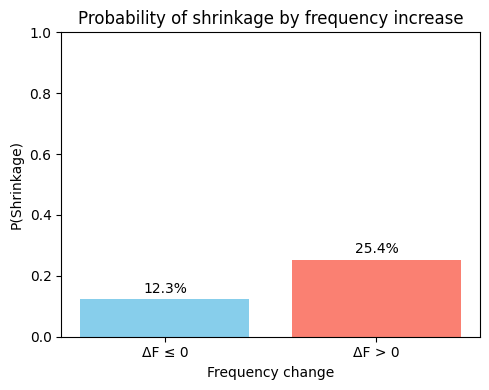

In [68]:
# plots
import matplotlib.pyplot as plt

trend = pd.Series({
    "ΔF ≤ 0": p_shrink_given_no_increase,
    "ΔF > 0": p_shrink_given_increase
})

plt.figure(figsize=(5,4))
bars = plt.bar(trend.index, trend.values, color=["skyblue", "salmon"])
plt.ylim(0,1)
plt.ylabel("P(Shrinkage)")
plt.xlabel("Frequency change")
plt.title("Probability of shrinkage by frequency increase")

# etichette sopra le barre
for bar, value in zip(bars, trend.values):
    plt.text(bar.get_x() + bar.get_width()/2, value + 0.02, f"{value*100:.1f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()






Create a CSV file containing all relevant information for the analyzed subset

(i.e., tokens appearing in at least 5 snapshots).


The file 'token_info_filtered_with_complexity.csv' includes:

    1. token: the token itself

    2. Si: semantic shrinkage for each year

    3. Freq: frequency for each year

    4. S_aggr: aggregated shrinkage

    5. Complexity metrics:

        5.1 char_len: number of characters in the 
        
        5.2 syll_len: number of syllables

        5.3 demauro_level: De Mauro complexity level
        
        5.4 idf: inverse document frequency



In [69]:
import pandas as pd
from pathlib import Path
import igraph as ig

# --- Percorsi ---
shrink_csv = "shrinkage_i.csv"
freq_dir = Path(r"../embedding/frequencies_all")
sagg_file = Path(r"shrinkage_aggr_filtered.csv")
graph_dir = Path(r"networks_annotated")
output_csv = "token_info_filtered_with_complexity.csv"

snapshots = range(1, 8)

# --- Carico shrinkage ---
df_shrink = pd.read_csv(shrink_csv)


# --- Carico frequenze per tutti gli snapshot ---
freq_dfs = []
for snap in snapshots:
    freq_file = freq_dir / f"vocab_freq_snap{snap}.csv"  # estensione corretta

    # Leggo CSV con header
    df_freq = pd.read_csv(freq_file)

    # Rinomino colonne per uniformità
    df_freq = df_freq.rename(columns={
        "word": "token",
        "frequency": f"freq_snap{snap}"
    })

    # Assicuro i tipi
    df_freq["token"] = df_freq["token"].astype(str)
    df_freq[f"freq_snap{snap}"] = df_freq[f"freq_snap{snap}"].astype(int)

    freq_dfs.append(df_freq)


# Merge di tutte le frequenze
df_freq_all = freq_dfs[0]
for df_f in freq_dfs[1:]:
    df_freq_all = df_freq_all.merge(df_f, on="token", how="outer")

# --- Filtra token presenti in almeno 5 snapshot ---
appear_count = (df_freq_all.iloc[:, 1:] > 0).sum(axis=1)
mask = appear_count >= 5
df_freq_all = df_freq_all[mask]

# --- Filtra df_shrink per token validi ---
df_shrink = df_shrink[df_shrink["token"].isin(df_freq_all["token"])]

# --- Merge shrinkage + frequenze ---
df_all = df_shrink.merge(df_freq_all, on="token", how="inner")

# --- Aggiungo S_aggregato dal file esterno ---
df_sagg = pd.read_csv(sagg_file)
df_all = df_all.merge(df_sagg, on="token", how="left")

# --- COSTRUISCO COMPLESSITÀ ---
complexity_data = {}

for snap in snapshots:
    graph_file = graph_dir / f"graph_snap{snap}_p99.igp"
    G = ig.Graph.Read_Pickle(graph_file)
    
    for v in G.vs:
        token = v["token"]
        if token not in complexity_data:
            complexity_data[token] = {
                "char_len": v["char_len"],
                "syll_len": v["syll_len"],
                "demauro_level": v["demauro_level"],
                "idf": v["idf"]
            }

# --- Merge complessità con df_all ---
df_complexity = pd.DataFrame.from_dict(complexity_data, orient="index").reset_index().rename(columns={"index": "token"})
df_all = df_all.merge(df_complexity, on="token", how="left")

# --- Salvataggio finale ---
df_all.to_csv(output_csv, index=False)
print(f"[DONE] CSV completo con complessità creato in {output_csv}")


[DONE] CSV completo con complessità creato in token_info_filtered_with_complexity.csv


In [70]:
len(df_all)

27144

# Expand RQ1 with complexity
Analyze the aggregated shrinkage (S_aggr) and the complexity metrics of the tokens.

In [71]:
# G.vs["char_len"] -> lunghezza parola
# G.vs["syll_len"] -> lunghezza in termini di sillabe
# G.vs["demauro_level"] -> 0,1,2: appartiene al vocabolario di base; 3: non appartiene al vocabolario di base (i.e., è "complessa")
# G.vs["idf"] -> inverse document frquency (più è alta, più la parola è complessa)


In [ ]:
df["shrink"] = df["S_aggregato"] > 0

pd.crosstab(
    df["demauro_level"] == 3,   # parola complessa
    df["shrink"],
    normalize="index"
)


In [ ]:
from scipy.stats import chi2_contingency

ct = pd.crosstab(df["demauro_level"] == 3, df["shrink"])
chi2, p, _, _ = chi2_contingency(ct)
print(p)


2.0395007272464605e-85


# Weight edge study 

In [ ]:
import igraph as ig
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Directory dei grafi
graph_dir = Path(r"networks")
graph_files = sorted(graph_dir.glob("graph_snap*_p99.igp"))

all_weights = []
heavy_edges_info = []

percentile_heavy = 95  # soglia per archi pesanti

print(f"[START] Analisi di {len(graph_files)} snapshot")

for i, gf in enumerate(graph_files, start=1):
    print(f"\n[SNAPSHOT {i}/{len(graph_files)}] Caricamento {gf.name}")
    g = ig.Graph.Read_Pickle(gf)

    if "weight" not in g.es.attribute_names():
        print("Nessun peso sugli archi, salto snapshot")
        continue

    weights = np.array(g.es["weight"])
    all_weights.extend(weights)

    threshold = np.percentile(weights, percentile_heavy)
    heavy_edges = [e.index for e in g.es if e["weight"] >= threshold]

    print(f"Totale archi: {g.ecount()}, archi pesanti (> {percentile_heavy}° percentile): {len(heavy_edges)}")

    for e_idx in heavy_edges:
        e = g.es[e_idx]
        src, dst = e.tuple
        heavy_edges_info.append({
            "snapshot": gf.stem,
            "source": g.vs[src]["token"],
            "target": g.vs[dst]["token"],
            "weight": e["weight"]
        })

print("\n[END] Analisi completata su tutti gli snapshot")



# # ---------- Archi pesanti ----------
# df_heavy = pd.DataFrame(heavy_edges_info)
# print("\nTop 20 archi più pesanti:")
# print(df_heavy.sort_values("weight", ascending=False).head(20))


[START] Analisi di 7 snapshot

[SNAPSHOT 1/7] Caricamento graph_snap1_p99.igp
Totale archi: 6102158, archi pesanti (> 95° percentile): 305112

[SNAPSHOT 2/7] Caricamento graph_snap2_p99.igp
Totale archi: 3951749, archi pesanti (> 95° percentile): 197593

[SNAPSHOT 3/7] Caricamento graph_snap3_p99.igp
Totale archi: 3923413, archi pesanti (> 95° percentile): 196176

[SNAPSHOT 4/7] Caricamento graph_snap4_p99.igp
Totale archi: 6018030, archi pesanti (> 95° percentile): 300908

[SNAPSHOT 5/7] Caricamento graph_snap5_p99.igp
Totale archi: 6906542, archi pesanti (> 95° percentile): 345329

[SNAPSHOT 6/7] Caricamento graph_snap6_p99.igp
Totale archi: 7168835, archi pesanti (> 95° percentile): 358452

[SNAPSHOT 7/7] Caricamento graph_snap7_p99.igp
Totale archi: 4792121, archi pesanti (> 95° percentile): 239612

[END] Analisi completata su tutti gli snapshot


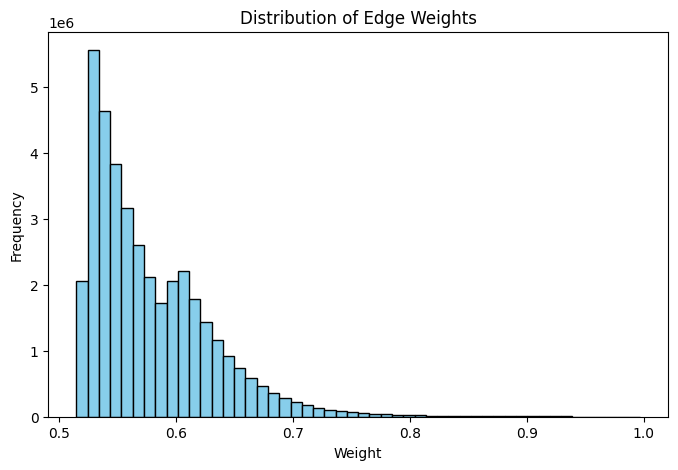

In [ ]:
all_weights = np.array(all_weights)

plt.figure(figsize=(8,5))
plt.hist(all_weights, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Edge Weights")
plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.show()


<Figure size 1600x600 with 0 Axes>

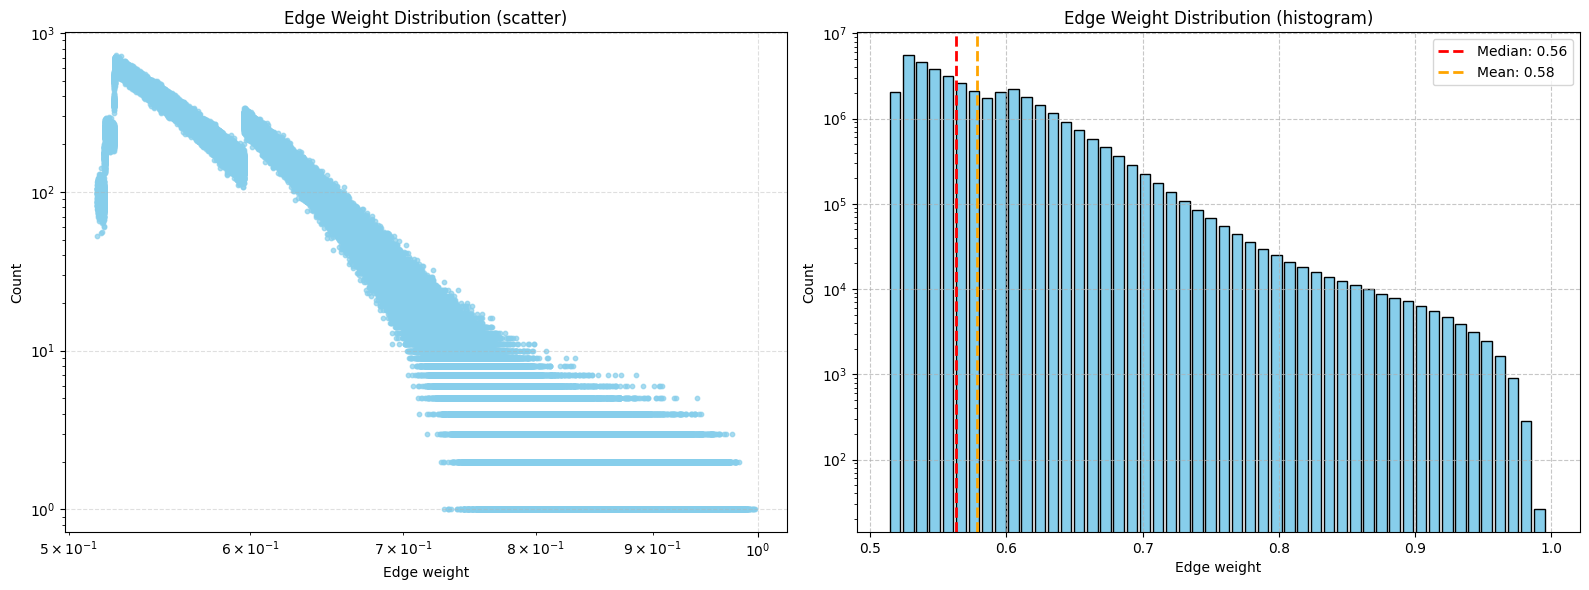

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Supponiamo che all_weights sia già un array numpy
all_weights = np.array(all_weights)

# Contiamo la frequenza di ogni peso
unique_weights, counts = np.unique(all_weights, return_counts=True)

# Histogram bins simili a quelli usati per i gradi
bin_width = (all_weights.max() - all_weights.min()) / 50  # 50 bins
bins = np.arange(all_weights.min(), all_weights.max() + bin_width, bin_width)

plt.figure(figsize=(16,6))
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# --- Scatter plot ---
axes[0].scatter(unique_weights, counts, alpha=0.7, s=10, color='skyblue')
axes[0].set_xlabel("Edge weight")
axes[0].set_ylabel("Count")
axes[0].set_title("Edge Weight Distribution (scatter)")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].grid(True, linestyle="--", alpha=0.4)

# --- Histogram ---
axes[1].hist(all_weights, bins=bins, color='skyblue', edgecolor='black', width=bin_width*0.8)
median_weight = np.median(all_weights)
mean_weight = np.mean(all_weights)

axes[1].axvline(median_weight, color='red', linestyle='--', linewidth=2, label=f"Median: {median_weight:.2f}")
axes[1].axvline(mean_weight, color='orange', linestyle='--', linewidth=2, label=f"Mean: {mean_weight:.2f}")

axes[1].set_xlabel("Edge weight")
axes[1].set_ylabel("Count")
axes[1].set_title("Edge Weight Distribution (histogram)")
axes[1].set_yscale("log")
axes[1].grid(True, linestyle="--", alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
# Mostrare tutte le righe senza troncamento
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)  # larghezza del terminale
pd.set_option("display.max_colwidth", None)

# ---------- Archi pesanti ----------
df_heavy = pd.DataFrame(heavy_edges_info)
print("\nTop 300 archi più pesanti:")
print(df_heavy.sort_values("weight", ascending=False).head(300))



Top 300 archi più pesanti:
                snapshot                source               target    weight
1160283  graph_snap5_p99              mmmmmmmm              mmmmmmm  0.996928
1202691  graph_snap5_p99                mmmmmm              mmmmmmm  0.996261
1238662  graph_snap5_p99    fondicriinternazre     fondicriinternaz  0.995070
262412   graph_snap1_p99    autoferrotranviero   autoferrotranviere  0.995024
1679064  graph_snap6_p99        teatridithalia       teatridithalio  0.994066
956468   graph_snap4_p99    autoferrotranviero   autoferrotranviere  0.993182
671386   graph_snap3_p99    autoferrotranviero   autoferrotranviere  0.992464
474322   graph_snap2_p99    autoferrotranviero   autoferrotranviere  0.991648
1075896  graph_snap5_p99         antimeridiana        antimeridiano  0.991603
1107415  graph_snap5_p99           capitalgest           capitalges  0.991446
1028165  graph_snap5_p99         phenixfundtop           phenixfund  0.991311
279978   graph_snap1_p99          mo